# 04b — Service Quality Depth: Headway, Evening Isolation & Sunday Deserts

**Purpose:** Move beyond trip counts to actual service quality — headway, span of service,
evening isolation, Sunday deserts, and a composite quality index. These are the metrics
policy makers use to distinguish adequate from inadequate bus provision.

**Inputs:**
- `data/raw/bods/bods_gtfs_all.zip` → stop_times.txt (5.8 GB), calendar.txt, trips.txt, stops.txt
- `data/audit/master_lsoa_table.parquet` — LSOA socio-economic data
- `data/audit/lsoa_service_levels.parquet` — existing trip counts from 02g
- `data/audit/lsoa_accessibility.parquet` — stop-to-LSOA spatial data from 02h
- `data/audit/lsoa_feature_matrix_clustered.parquet` — LSOA archetypes from 02e

**Outputs:**
- `data/audit/stop_headways.parquet` — per-stop headway statistics by day type and time band
- `data/audit/lsoa_service_quality.parquet` — per-LSOA quality metrics and composite index

**Key policy metrics:**
- Mean weekday headway (minutes between buses)
- Peak/interpeak headway ratio (service reliability signal)
- Evening isolation (no service after 19:00)
- Sunday desert (zero Sunday trips)
- Service quality index (0–100 composite)

In [1]:
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RAW = Path('../data/raw')
AUDIT = Path('../data/audit')
BODS_ZIP = RAW / 'bods' / 'bods_gtfs_all.zip'

# Time period boundaries (minutes from midnight)
AM_PEAK_START = 7 * 60       # 07:00
AM_PEAK_END = 9 * 60 + 30    # 09:30
INTERPEAK_START = AM_PEAK_END
INTERPEAK_END = 16 * 60      # 16:00
PM_PEAK_START = INTERPEAK_END
PM_PEAK_END = 18 * 60 + 30   # 18:30
EVENING_START = PM_PEAK_END  # 18:30
EVENING_THRESHOLD = 19 * 60  # 19:00 — evening isolated if last bus before this
NIGHT_THRESHOLD = 22 * 60    # 22:00 — night isolated

logger.info('04b_service_quality_depth starting')

2026-03-14 00:40:11.691 | INFO     | __main__:<module>:29 - 04b_service_quality_depth starting


## 1. Load Supporting Tables

In [2]:
with zipfile.ZipFile(BODS_ZIP) as z:
    with z.open('calendar.txt') as f:
        calendar = pd.read_csv(f)
    with z.open('trips.txt') as f:
        trips = pd.read_csv(f, usecols=['trip_id', 'route_id', 'service_id'])
    with z.open('stops.txt') as f:
        stops = pd.read_csv(f, usecols=['stop_id', 'stop_lat', 'stop_lon'])

master = pd.read_parquet(AUDIT / 'master_lsoa_table.parquet')
lsoa_acc = pd.read_parquet(AUDIT / 'lsoa_accessibility.parquet')
lsoa_svc = pd.read_parquet(AUDIT / 'lsoa_service_levels.parquet')

# Cluster archetypes (02e output)
clustered = pd.read_parquet(AUDIT / 'lsoa_feature_matrix_clustered.parquet')
archetype_map = {0: 'Affluent Urban', 1: 'Deprived Young Diverse', 2: 'Elderly Rural', 3: 'Deprived Car-Free Urban'}
if 'cluster' in clustered.columns:
    cluster_lsoa = clustered[['lsoa_cd', 'cluster']].copy() if 'lsoa_cd' in clustered.columns else clustered[['LSOA21CD', 'cluster']].rename(columns={'LSOA21CD': 'lsoa_cd'})
else:
    cluster_lsoa = None
    logger.warning('No cluster column in clustered parquet')

logger.info(f'calendar: {len(calendar):,}, trips: {len(trips):,}, stops: {len(stops):,}')
print(f'calendar: {len(calendar):,} service patterns')
print(f'trips: {len(trips):,}')
print(f'master_lsoa_table: {master.shape}')
print(f'lsoa_accessibility: {lsoa_acc.shape}')

2026-03-14 00:40:13.592 | INFO     | __main__:<module>:22 - calendar: 2,105, trips: 1,752,443, stops: 310,598


calendar: 2,105 service patterns
trips: 1,752,443
master_lsoa_table: (33755, 50)
lsoa_accessibility: (33755, 11)


In [3]:
# Classify service_id by day type using calendar
# weekday = runs monday–friday; saturday; sunday
# A service_id may run on multiple day types — classify by which days it runs
calendar['is_weekday'] = (
    (calendar['monday'] | calendar['tuesday'] | calendar['wednesday']
     | calendar['thursday'] | calendar['friday']).astype(bool)
)
calendar['is_saturday'] = calendar['saturday'].astype(bool)
calendar['is_sunday'] = calendar['sunday'].astype(bool)

# Build trip → day_type mapping (a trip can run on multiple day types)
# For headway computation we need trips that run on each day type
weekday_service_ids = set(calendar[calendar['is_weekday']]['service_id'])
saturday_service_ids = set(calendar[calendar['is_saturday']]['service_id'])
sunday_service_ids = set(calendar[calendar['is_sunday']]['service_id'])

trips['trip_id'] = trips['trip_id'].astype(str)
weekday_trip_ids = set(trips[trips['service_id'].isin(weekday_service_ids)]['trip_id'])
saturday_trip_ids = set(trips[trips['service_id'].isin(saturday_service_ids)]['trip_id'])
sunday_trip_ids = set(trips[trips['service_id'].isin(sunday_service_ids)]['trip_id'])

print(f'Weekday trips: {len(weekday_trip_ids):,}')
print(f'Saturday trips: {len(saturday_trip_ids):,}')
print(f'Sunday trips: {len(sunday_trip_ids):,}')

all_typed_trip_ids = weekday_trip_ids | saturday_trip_ids | sunday_trip_ids
print(f'Total trips with known day type: {len(all_typed_trip_ids):,}')

Weekday trips: 828,615
Saturday trips: 523,855
Sunday trips: 312,271
Total trips with known day type: 1,637,565


## 2. Parse Departure Times from stop_times.txt (Chunked)

In [4]:
def parse_gtfs_time(time_str: str) -> int:
    """Convert GTFS HH:MM:SS to minutes from midnight. Handles >24:00 for post-midnight trips."""
    try:
        h, m, _ = time_str.split(':')
        return int(h) * 60 + int(m)
    except Exception:
        return -1


def time_band(minutes: int) -> str:
    """Classify minutes-from-midnight into service time band."""
    if minutes < 0:
        return 'unknown'
    if minutes < AM_PEAK_START:
        return 'early'
    if minutes < AM_PEAK_END:
        return 'am_peak'
    if minutes < INTERPEAK_END:
        return 'interpeak'
    if minutes < PM_PEAK_END:
        return 'pm_peak'
    return 'evening'

In [5]:
# Read stop_times in chunks, keep only departures for typed trips
# Collect: stop_id, departure_minutes, day_type (weekday/saturday/sunday)
# Only first stop visit per trip (sequence=0 or min sequence) gives the service span start
# For headway: we need ALL stops × all departures × day_type
# Memory strategy: accumulate (stop_id, day_type) → sorted list of departure_minutes

CHUNK_SIZE = 1_000_000

# For each (stop_id, day_type): list of departure times in minutes
stop_day_departures: dict[tuple[str, str], list[int]] = {}

# For evening/Sunday analysis: last departure per (stop_id, day_type)
stop_day_last: dict[tuple[str, str], int] = {}

logger.info('Reading stop_times.txt for service quality metrics (chunked)...')
chunks_read = 0

with zipfile.ZipFile(BODS_ZIP) as z:
    with z.open('stop_times.txt') as raw_f:
        reader = pd.read_csv(
            raw_f,
            usecols=['trip_id', 'departure_time', 'stop_id'],
            dtype={'trip_id': str, 'stop_id': str, 'departure_time': str},
            chunksize=CHUNK_SIZE,
        )
        for chunk in reader:
            # Filter to typed trips only
            chunk = chunk[chunk['trip_id'].isin(all_typed_trip_ids)].copy()
            if chunk.empty:
                chunks_read += 1
                continue

            # Parse departure time
            chunk['dep_min'] = chunk['departure_time'].apply(parse_gtfs_time)
            chunk = chunk[chunk['dep_min'] >= 0]

            # Tag day type (a trip may belong to multiple — assign primary priority: weekday > saturday > sunday)
            def get_day_type(tid: str) -> str:
                if tid in weekday_trip_ids:
                    return 'weekday'
                if tid in saturday_trip_ids:
                    return 'saturday'
                return 'sunday'

            chunk['day_type'] = chunk['trip_id'].map(get_day_type)

            # Accumulate departures per (stop_id, day_type)
            for (stop_id, day_type), grp in chunk.groupby(['stop_id', 'day_type']):
                key = (stop_id, day_type)
                dep_list = grp['dep_min'].tolist()
                if key not in stop_day_departures:
                    stop_day_departures[key] = dep_list
                else:
                    stop_day_departures[key].extend(dep_list)

            chunks_read += 1
            if chunks_read % 20 == 0:
                logger.info(f'  chunk {chunks_read}: {len(stop_day_departures):,} (stop, day_type) pairs')

logger.info(f'stop_times read complete: {len(stop_day_departures):,} (stop, day_type) pairs')
print(f'Total (stop_id, day_type) departure series: {len(stop_day_departures):,}')

2026-03-14 00:40:14.710 | INFO     | __main__:<module>:15 - Reading stop_times.txt for service quality metrics (chunked)...


2026-03-14 00:46:27.873 | INFO     | __main__:<module>:58 -   chunk 20: 722,782 (stop, day_type) pairs


2026-03-14 00:52:50.085 | INFO     | __main__:<module>:58 -   chunk 40: 747,875 (stop, day_type) pairs


2026-03-14 00:59:18.236 | INFO     | __main__:<module>:58 -   chunk 60: 755,702 (stop, day_type) pairs


2026-03-14 01:02:15.308 | INFO     | __main__:<module>:60 - stop_times read complete: 757,381 (stop, day_type) pairs


Total (stop_id, day_type) departure series: 757,381


## 3. Compute Headway Statistics per Stop

In [6]:
def compute_headway_stats(departures: list[int]) -> dict:
    """Compute headway statistics from a sorted list of departure minutes.
    
    Args:
        departures: Departure times in minutes from midnight (may be unsorted).
    
    Returns:
        Dict with headway metrics: n_trips, mean_headway_min, median_headway_min,
        max_headway_min, cov_headway, first_dep, last_dep, span_min.
    """
    deps = sorted(set(departures))  # deduplicate then sort
    n = len(deps)
    if n == 0:
        return {'n_trips': 0, 'mean_headway_min': None, 'median_headway_min': None,
                'max_headway_min': None, 'cov_headway': None,
                'first_dep': None, 'last_dep': None, 'span_min': None}
    first_dep = deps[0]
    last_dep = deps[-1]
    span_min = last_dep - first_dep
    if n == 1:
        return {'n_trips': 1, 'mean_headway_min': None, 'median_headway_min': None,
                'max_headway_min': None, 'cov_headway': None,
                'first_dep': first_dep, 'last_dep': last_dep, 'span_min': span_min}
    gaps = [deps[i + 1] - deps[i] for i in range(n - 1)]
    gaps_arr = np.array(gaps, dtype=float)
    mean_h = float(gaps_arr.mean())
    std_h = float(gaps_arr.std())
    return {
        'n_trips': n,
        'mean_headway_min': round(mean_h, 1),
        'median_headway_min': round(float(np.median(gaps_arr)), 1),
        'max_headway_min': round(float(gaps_arr.max()), 1),
        'cov_headway': round(std_h / mean_h, 3) if mean_h > 0 else None,
        'first_dep': first_dep,
        'last_dep': last_dep,
        'span_min': span_min,
    }


# Compute headways for all (stop, day_type) pairs
rows = []
for (stop_id, day_type), departures in stop_day_departures.items():
    stats = compute_headway_stats(departures)
    stats['stop_id'] = stop_id
    stats['day_type'] = day_type

    # Time-band departure counts for peak/interpeak ratio
    deps_sorted = sorted(departures)
    stats['n_am_peak'] = sum(1 for d in deps_sorted if AM_PEAK_START <= d < AM_PEAK_END)
    stats['n_interpeak'] = sum(1 for d in deps_sorted if INTERPEAK_START <= d < INTERPEAK_END)
    stats['n_pm_peak'] = sum(1 for d in deps_sorted if PM_PEAK_START <= d < PM_PEAK_END)
    stats['n_evening'] = sum(1 for d in deps_sorted if d >= EVENING_START)

    rows.append(stats)

stop_headways = pd.DataFrame(rows)

# Compute peak-to-interpeak headway ratio
# Ratio = (span / n_interpeak) / (span / n_am_peak) ≈ n_am_peak / n_interpeak
# Simpler: trips_per_hour in AM peak vs interpeak
stop_headways['am_peak_tph'] = np.where(
    stop_headways['n_am_peak'] > 0,
    stop_headways['n_am_peak'] / 2.5,  # 2.5 hours
    0.0
)
stop_headways['interpeak_tph'] = np.where(
    stop_headways['n_interpeak'] > 0,
    stop_headways['n_interpeak'] / 6.5,  # 6.5 hours
    0.0
)
stop_headways['peak_interpeak_ratio'] = np.where(
    stop_headways['interpeak_tph'] > 0,
    (stop_headways['am_peak_tph'] / stop_headways['interpeak_tph']).round(2),
    None
)

print(f'stop_headways shape: {stop_headways.shape}')
print(f'Columns: {list(stop_headways.columns)}')
print(f'\nWeekday headway stats (mean):')
wd = stop_headways[stop_headways['day_type'] == 'weekday']
print(wd['mean_headway_min'].describe().round(1))

stop_headways shape: (757381, 17)
Columns: ['n_trips', 'mean_headway_min', 'median_headway_min', 'max_headway_min', 'cov_headway', 'first_dep', 'last_dep', 'span_min', 'stop_id', 'day_type', 'n_am_peak', 'n_interpeak', 'n_pm_peak', 'n_evening', 'am_peak_tph', 'interpeak_tph', 'peak_interpeak_ratio']

Weekday headway stats (mean):
count    287217.0
mean         50.7
std          59.5
min           1.0
25%          16.2
50%          33.3
75%          63.3
max        1506.0
Name: mean_headway_min, dtype: float64


In [7]:
# Save stop_headways
stop_headways.to_parquet(AUDIT / 'stop_headways.parquet', index=False)
logger.info(f'Saved stop_headways.parquet: {stop_headways.shape}')
print(f'Saved stop_headways.parquet: {stop_headways.shape}')

2026-03-14 01:02:49.570 | INFO     | __main__:<module>:3 - Saved stop_headways.parquet: (757381, 17)


Saved stop_headways.parquet: (757381, 17)


## 4. Headway Distribution Analysis

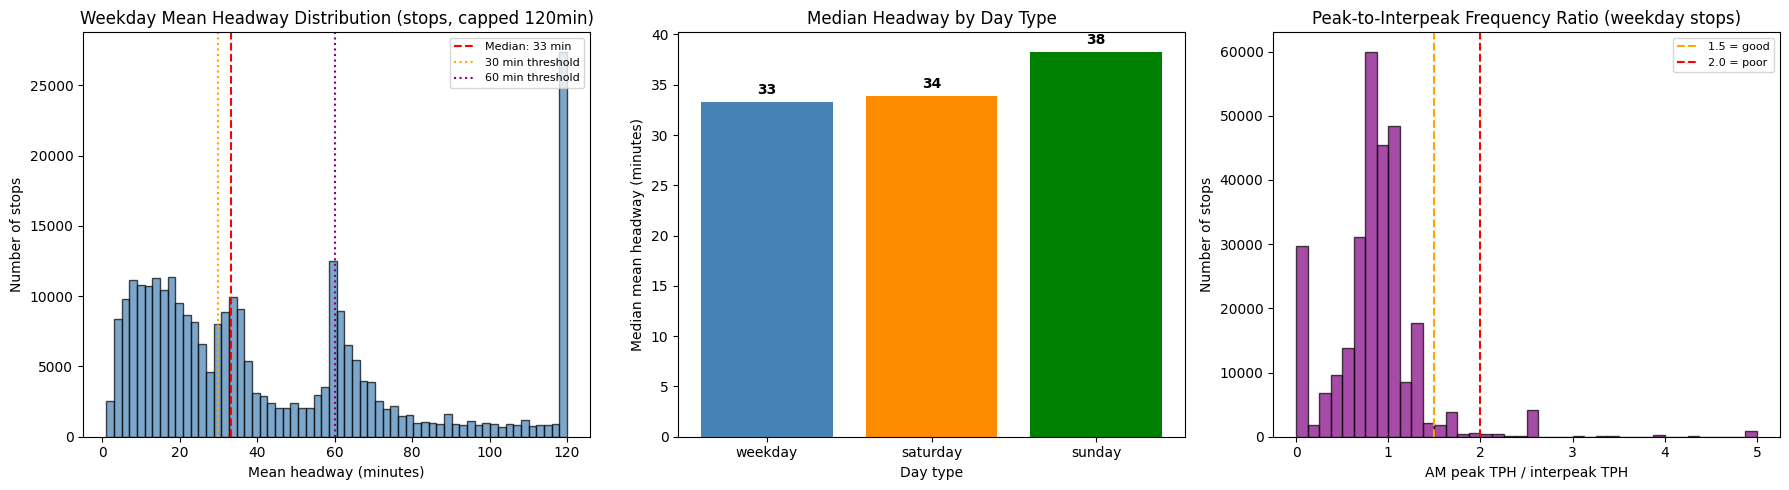

Saved fig_04b_headway_distribution.png


In [8]:
wd_headways = stop_headways[stop_headways['day_type'] == 'weekday'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean headway distribution (capped at 120 min for readability)
capped = wd_headways['mean_headway_min'].dropna().clip(upper=120)
axes[0].hist(capped, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(wd_headways['mean_headway_min'].median(), color='red', linestyle='--',
                label=f'Median: {wd_headways["mean_headway_min"].median():.0f} min')
axes[0].axvline(30, color='orange', linestyle=':', label='30 min threshold')
axes[0].axvline(60, color='purple', linestyle=':', label='60 min threshold')
axes[0].set_title('Weekday Mean Headway Distribution (stops, capped 120min)')
axes[0].set_xlabel('Mean headway (minutes)')
axes[0].set_ylabel('Number of stops')
axes[0].legend(fontsize=8)

# Headway by day type — median comparison
median_by_day = stop_headways.groupby('day_type')['mean_headway_min'].median().reindex(['weekday', 'saturday', 'sunday'])
colors = ['steelblue', 'darkorange', 'green']
bars = axes[1].bar(median_by_day.index, median_by_day.values, color=colors)
axes[1].set_title('Median Headway by Day Type')
axes[1].set_xlabel('Day type')
axes[1].set_ylabel('Median mean headway (minutes)')
for bar, val in zip(bars, median_by_day.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{val:.0f}', ha='center', va='bottom', fontweight='bold')

# Peak-to-interpeak ratio distribution
pir = wd_headways['peak_interpeak_ratio'].dropna().clip(upper=5)
axes[2].hist(pir, bins=40, edgecolor='black', alpha=0.7, color='purple')
axes[2].axvline(1.5, color='orange', linestyle='--', label='1.5 = good')
axes[2].axvline(2.0, color='red', linestyle='--', label='2.0 = poor')
axes[2].set_title('Peak-to-Interpeak Frequency Ratio (weekday stops)')
axes[2].set_xlabel('AM peak TPH / interpeak TPH')
axes[2].set_ylabel('Number of stops')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(AUDIT / 'fig_04b_headway_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_04b_headway_distribution.png')

## 5. LSOA-Level Service Quality Metrics

In [9]:
# Join stops → LSOAs via lsoa_accessibility
# lsoa_accessibility has per-LSOA nearest stop info but not stop→LSOA mapping
# We need: for each LSOA, what is the headway/service quality of stops within it

# Strategy: use master_lsoa_table stop_count + stops.txt locations
# For LSOA-level quality: spatial join stops → LSOA, then aggregate stop headways

# Load LSOA boundary data (centroids approximation: use lsoa_accessibility stop dist)
# Better: load actual stop-to-LSOA mapping from 01_data_audit or 02h spatial analysis
# Check if bods_stop_frequency has LSOA info
stop_freq = pd.read_parquet(AUDIT / 'bods_stop_frequency.parquet')
print('bods_stop_frequency cols:', list(stop_freq.columns))

# No LSOA column in stop_frequency — need to build stop → LSOA mapping
# Use stops.txt coords + LSOA boundary spatial join (same approach as 04a)
import geopandas as gpd

LSOA_GEOJSON = RAW / 'boundaries' / 'lsoa_2021_england_buc.geojson'
lsoa_gdf = gpd.read_file(LSOA_GEOJSON)[['LSOA21CD', 'geometry']].to_crs('EPSG:27700')

ENGLAND_LAT = (49.8, 55.9)
ENGLAND_LON = (-6.5, 1.9)

stops_eng = stops[
    stops['stop_lat'].between(*ENGLAND_LAT) &
    stops['stop_lon'].between(*ENGLAND_LON)
].copy()
stops_eng['stop_id'] = stops_eng['stop_id'].astype(str)

stops_gdf = gpd.GeoDataFrame(
    stops_eng,
    geometry=gpd.points_from_xy(stops_eng['stop_lon'], stops_eng['stop_lat']),
    crs='EPSG:4326',
).to_crs('EPSG:27700')

logger.info('Spatial join: stops → LSOA...')
stop_lsoa = gpd.sjoin(
    stops_gdf[['stop_id', 'geometry']],
    lsoa_gdf,
    how='left', predicate='within'
)[['stop_id', 'LSOA21CD']].drop_duplicates(subset='stop_id')

matched = stop_lsoa['LSOA21CD'].notna().sum()
print(f'England stops → LSOA matched: {matched:,} of {len(stops_eng):,} ({matched / len(stops_eng) * 100:.1f}%)')

bods_stop_frequency cols: ['stop_id', 'total_visits', 'band']


2026-03-14 01:03:29.666 | INFO     | __main__:<module>:36 - Spatial join: stops → LSOA...


England stops → LSOA matched: 252,473 of 286,840 (88.0%)


In [10]:
# Merge weekday headways with stop→LSOA mapping
wd_with_lsoa = (
    wd_headways[['stop_id', 'n_trips', 'mean_headway_min', 'median_headway_min',
                 'max_headway_min', 'cov_headway', 'first_dep', 'last_dep',
                 'span_min', 'peak_interpeak_ratio', 'n_am_peak', 'n_interpeak',
                 'n_pm_peak', 'n_evening']]
    .merge(stop_lsoa, on='stop_id', how='left')
)

# Sunday trips per stop → LSOA
sun_headways = stop_headways[stop_headways['day_type'] == 'sunday'][['stop_id', 'n_trips']].rename(
    columns={'n_trips': 'sunday_trips'}
)
wd_with_lsoa = wd_with_lsoa.merge(sun_headways, on='stop_id', how='left')
wd_with_lsoa['sunday_trips'] = wd_with_lsoa['sunday_trips'].fillna(0)

# Aggregate per LSOA
lsoa_quality = (
    wd_with_lsoa
    .dropna(subset=['LSOA21CD'])
    .groupby('LSOA21CD')
    .agg(
        n_stops_with_service=('stop_id', 'count'),
        mean_headway_min=('mean_headway_min', 'mean'),
        median_headway_min=('median_headway_min', 'median'),
        cov_headway=('cov_headway', 'mean'),
        first_service_min=('first_dep', 'min'),    # earliest first departure
        last_service_min=('last_dep', 'max'),       # latest last departure
        total_weekday_departures=('n_trips', 'sum'),
        total_sunday_departures=('sunday_trips', 'sum'),
        n_stops_with_evening=('n_evening', lambda x: (x > 0).sum()),
        peak_interpeak_ratio=('peak_interpeak_ratio', 'median'),
    )
    .reset_index()
)

print(f'LSOAs with service quality data: {len(lsoa_quality):,}')
print(f'Columns: {list(lsoa_quality.columns)}')

LSOAs with service quality data: 31,962
Columns: ['LSOA21CD', 'n_stops_with_service', 'mean_headway_min', 'median_headway_min', 'cov_headway', 'first_service_min', 'last_service_min', 'total_weekday_departures', 'total_sunday_departures', 'n_stops_with_evening', 'peak_interpeak_ratio']


In [11]:
# Ensure all 33,755 LSOAs present (zero-fill for no-service areas)
all_lsoas = pd.DataFrame({'LSOA21CD': lsoa_gdf['LSOA21CD'].values})
lsoa_quality = all_lsoas.merge(lsoa_quality, on='LSOA21CD', how='left')

# Evening isolation flags
lsoa_quality['evening_isolated'] = (
    lsoa_quality['last_service_min'].isna() |
    (lsoa_quality['last_service_min'] < EVENING_THRESHOLD)
)
lsoa_quality['night_isolated'] = (
    lsoa_quality['last_service_min'].isna() |
    (lsoa_quality['last_service_min'] < NIGHT_THRESHOLD)
)
lsoa_quality['sunday_desert'] = (
    lsoa_quality['total_sunday_departures'].isna() |
    (lsoa_quality['total_sunday_departures'] == 0)
)
lsoa_quality['sunday_minimal'] = (
    (~lsoa_quality['sunday_desert']) &
    (lsoa_quality['total_sunday_departures'] <= 4)
)
lsoa_quality['no_service'] = lsoa_quality['n_stops_with_service'].isna()

evening_iso = lsoa_quality['evening_isolated'].sum()
night_iso = lsoa_quality['night_isolated'].sum()
sun_desert = lsoa_quality['sunday_desert'].sum()
no_svc = lsoa_quality['no_service'].sum()

print(f'LSOAs with NO weekday service: {no_svc:,} ({no_svc / len(lsoa_quality) * 100:.1f}%)')
print(f'LSOAs evening isolated (last bus < 19:00): {evening_iso:,} ({evening_iso / len(lsoa_quality) * 100:.1f}%)')
print(f'LSOAs night isolated (last bus < 22:00): {night_iso:,} ({night_iso / len(lsoa_quality) * 100:.1f}%)')
print(f'LSOAs Sunday desert (0 Sunday trips): {sun_desert:,} ({sun_desert / len(lsoa_quality) * 100:.1f}%)')

LSOAs with NO weekday service: 1,793 (5.3%)
LSOAs evening isolated (last bus < 19:00): 5,189 (15.4%)
LSOAs night isolated (last bus < 22:00): 9,590 (28.4%)
LSOAs Sunday desert (0 Sunday trips): 6,745 (20.0%)


## 6. Composite Service Quality Index

In [12]:
# Composite index: 5 components, 0–100 each, then weighted sum
# 1. Headway score (40%): lower headway = better service
#    Score = max(0, 100 - (mean_headway / 60) * 100) — 0 min headway = 100, 60+ min = 0
# 2. Span score (20%): longer service day = better
#    Score = min(100, span_min / (18 * 60) * 100) — 18-hour span = 100
# 3. Frequency score (20%): trips per day
#    Score = min(100, total_weekday_departures / 100 * 100) — 100+ trips/day = 100
# 4. Evening score (10%): last service time
#    Score = min(100, max(0, (last_dep - 18*60) / (4*60) * 100)) — 18:00=0, 22:00=100
# 5. Sunday score (10%): Sunday trip ratio vs weekday
#    Score = min(100, total_sunday / max(total_weekday, 1) * 200) — ≥50% of weekday trips = 100

q = lsoa_quality.copy()

# Headway score
q['score_headway'] = np.where(
    q['mean_headway_min'].notna(),
    (100 - (q['mean_headway_min'] / 60 * 100)).clip(0, 100),
    0.0  # no service = 0
)

# Span score
service_span = (q['last_service_min'].fillna(0) - q['first_service_min'].fillna(0)).clip(lower=0)
q['score_span'] = (service_span / (18 * 60) * 100).clip(0, 100)

# Frequency score
q['score_frequency'] = (q['total_weekday_departures'].fillna(0) / 100 * 100).clip(0, 100)

# Evening score
q['score_evening'] = np.where(
    q['last_service_min'].notna(),
    ((q['last_service_min'] - 18 * 60) / (4 * 60) * 100).clip(0, 100),
    0.0
)

# Sunday score
q['score_sunday'] = np.where(
    q['total_weekday_departures'].fillna(0) > 0,
    (q['total_sunday_departures'].fillna(0) / q['total_weekday_departures'].fillna(1) * 200).clip(0, 100),
    0.0
)

# Composite
q['service_quality_index'] = (
    0.40 * q['score_headway']
    + 0.20 * q['score_span']
    + 0.20 * q['score_frequency']
    + 0.10 * q['score_evening']
    + 0.10 * q['score_sunday']
).round(1)

lsoa_quality = q

print(f'Service quality index range: {lsoa_quality["service_quality_index"].min():.1f} – {lsoa_quality["service_quality_index"].max():.1f}')
print(f'Service quality index mean: {lsoa_quality["service_quality_index"].mean():.1f}')
print(f'Service quality index median: {lsoa_quality["service_quality_index"].median():.1f}')
print(f'\nScore components (mean):')
for col in ['score_headway', 'score_span', 'score_frequency', 'score_evening', 'score_sunday']:
    print(f'  {col}: {lsoa_quality[col].mean():.1f}')

Service quality index range: 0.0 – 98.9
Service quality index mean: 65.4
Service quality index median: 73.5

Score components (mean):
  score_headway: 42.4
  score_span: 85.8
  score_frequency: 84.9
  score_evening: 79.6
  score_sunday: 63.3


## 7. Service Quality by LSOA Archetype

In [13]:
# Merge with master for IMD and archetype
lsoa_quality = lsoa_quality.merge(
    master[['lsoa_cd', 'imd_score', 'imd_decile', 'population', 'urban_rural']],
    left_on='LSOA21CD', right_on='lsoa_cd', how='left'
)

if cluster_lsoa is not None:
    lsoa_quality = lsoa_quality.merge(cluster_lsoa, left_on='LSOA21CD', right_on='lsoa_cd', how='left', suffixes=('', '_cluster'))
    lsoa_quality['archetype'] = lsoa_quality['cluster'].map(archetype_map).fillna('Unknown')

print(f'Merged shape: {lsoa_quality.shape}')
if 'archetype' in lsoa_quality.columns:
    print(f'Archetypes: {lsoa_quality["archetype"].value_counts().to_dict()}')

Merged shape: (33755, 30)
Archetypes: {'Affluent Urban': 16944, 'Deprived Car-Free Urban': 6200, 'Deprived Young Diverse': 6023, 'Elderly Rural': 4588}


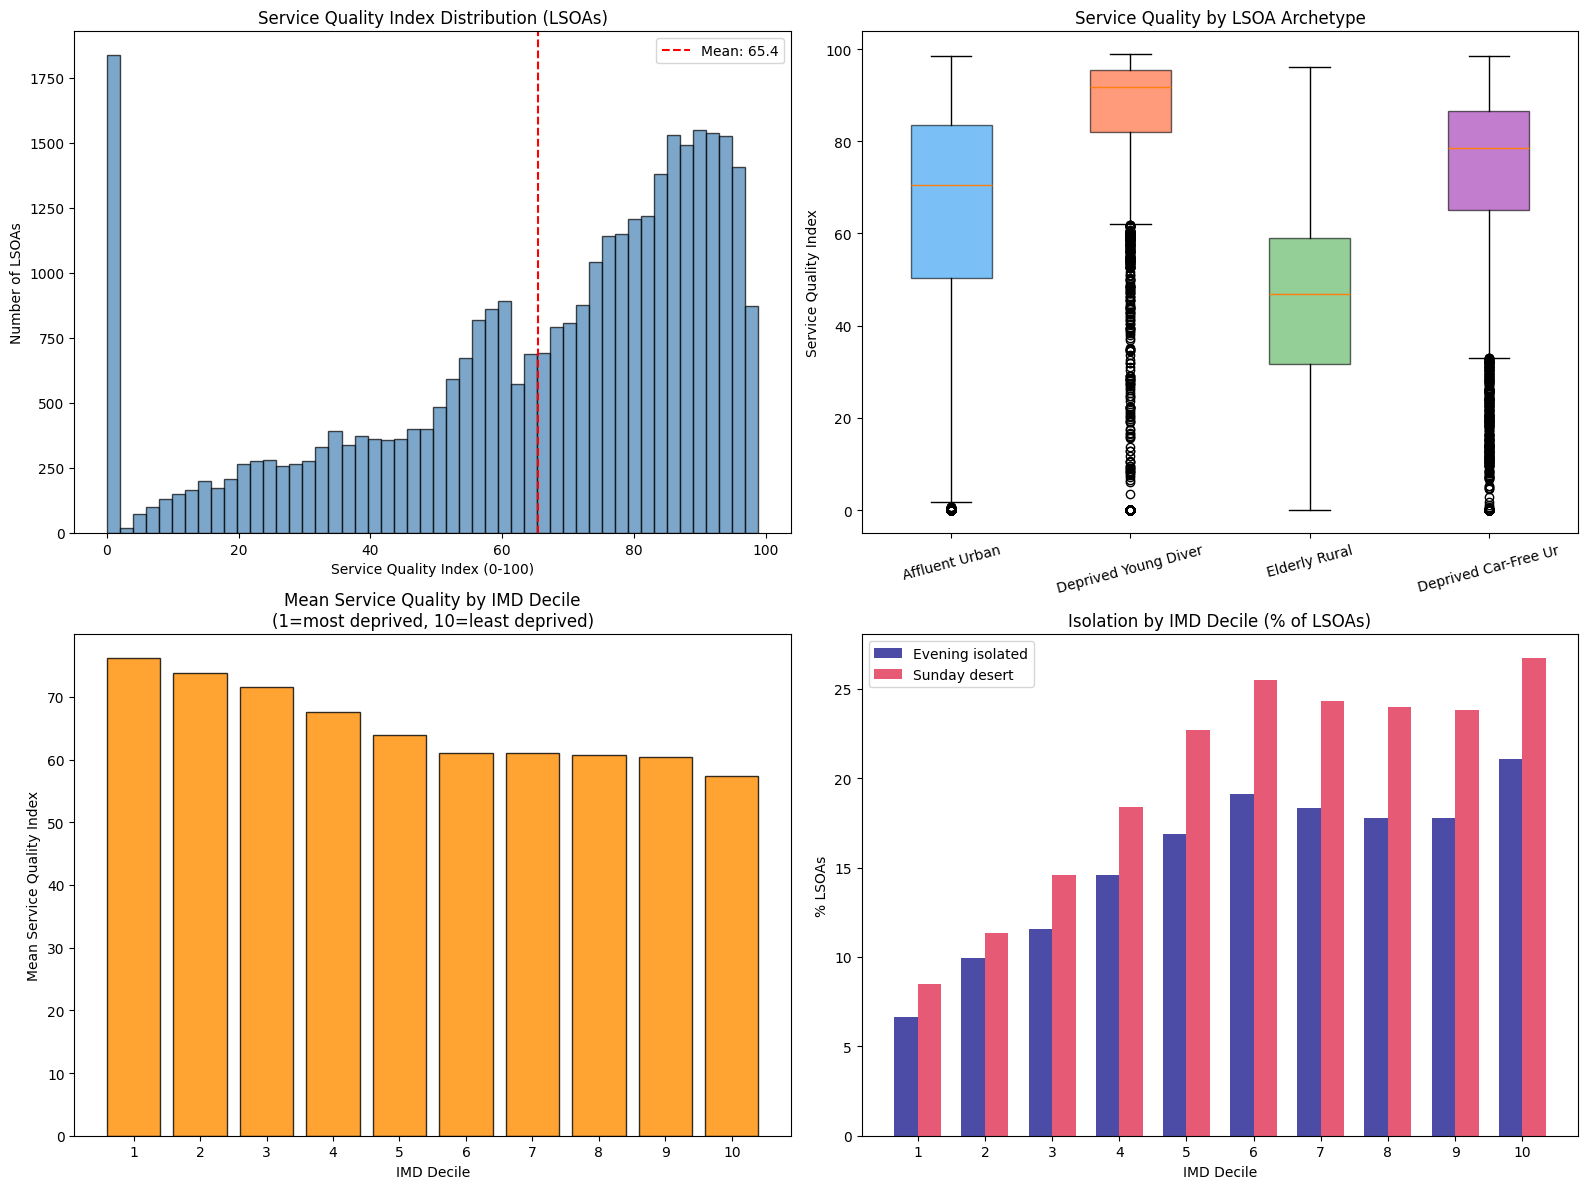

Saved fig_04b_service_quality.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Service quality index distribution
axes[0, 0].hist(lsoa_quality['service_quality_index'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(lsoa_quality['service_quality_index'].mean(), color='red', linestyle='--',
                   label=f'Mean: {lsoa_quality["service_quality_index"].mean():.1f}')
axes[0, 0].set_title('Service Quality Index Distribution (LSOAs)')
axes[0, 0].set_xlabel('Service Quality Index (0-100)')
axes[0, 0].set_ylabel('Number of LSOAs')
axes[0, 0].legend()

# Quality by archetype
if 'archetype' in lsoa_quality.columns:
    archetypes = [a for a in archetype_map.values() if a in lsoa_quality['archetype'].values]
    quality_by_arch = [lsoa_quality[lsoa_quality['archetype'] == a]['service_quality_index'].dropna().values
                       for a in archetypes]
    bp = axes[0, 1].boxplot(quality_by_arch, labels=[a[:20] for a in archetypes], patch_artist=True)
    colors_arch = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
    for patch, color in zip(bp['boxes'], colors_arch[:len(archetypes)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[0, 1].set_title('Service Quality by LSOA Archetype')
    axes[0, 1].set_ylabel('Service Quality Index')
    axes[0, 1].tick_params(axis='x', rotation=15)

# Quality vs IMD decile
imd_quality = lsoa_quality.dropna(subset=['imd_decile'])
mean_quality_by_decile = imd_quality.groupby('imd_decile')['service_quality_index'].mean()
axes[1, 0].bar(mean_quality_by_decile.index, mean_quality_by_decile.values, color='darkorange', edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Mean Service Quality by IMD Decile\n(1=most deprived, 10=least deprived)')
axes[1, 0].set_xlabel('IMD Decile')
axes[1, 0].set_ylabel('Mean Service Quality Index')
axes[1, 0].set_xticks(range(1, 11))

# Evening/Sunday isolation by IMD decile
isolation_by_decile = imd_quality.groupby('imd_decile').agg(
    evening_isolated_pct=('evening_isolated', 'mean'),
    sunday_desert_pct=('sunday_desert', 'mean'),
) * 100
x = isolation_by_decile.index
width = 0.35
axes[1, 1].bar(x - width/2, isolation_by_decile['evening_isolated_pct'], width, label='Evening isolated', color='navy', alpha=0.7)
axes[1, 1].bar(x + width/2, isolation_by_decile['sunday_desert_pct'], width, label='Sunday desert', color='crimson', alpha=0.7)
axes[1, 1].set_title('Isolation by IMD Decile (% of LSOAs)')
axes[1, 1].set_xlabel('IMD Decile')
axes[1, 1].set_ylabel('% LSOAs')
axes[1, 1].set_xticks(range(1, 11))
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(AUDIT / 'fig_04b_service_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_04b_service_quality.png')

## 8. Correlation: IMD vs Service Quality

In [15]:
from scipy import stats

valid = lsoa_quality.dropna(subset=['imd_score', 'service_quality_index'])
pearson_r, pearson_p = stats.pearsonr(valid['imd_score'], valid['service_quality_index'])
spearman_r, spearman_p = stats.spearmanr(valid['imd_score'], valid['service_quality_index'])

print(f'IMD score vs Service Quality Index:')
print(f'  Pearson r = {pearson_r:.4f} (p={pearson_p:.3e})')
print(f'  Spearman ρ = {spearman_r:.4f} (p={spearman_p:.3e})')
print(f'  Interpretation: positive IMD = more deprived → {'lower' if pearson_r < 0 else "higher"} quality')
print(f'  n = {len(valid):,} LSOAs')

# Population-weighted mean quality by IMD quintile
valid = valid.copy()
valid['imd_quintile'] = pd.qcut(valid['imd_score'], q=5, labels=['Q1 Most\nDeprived', 'Q2', 'Q3', 'Q4', 'Q5 Least\nDeprived'])
pop_weight = valid.groupby('imd_quintile', observed=True).apply(
    lambda g: np.average(g['service_quality_index'], weights=g['population'].fillna(1))
).round(1)
print(f'\nPop-weighted mean quality by IMD quintile:')
print(pop_weight)

IMD score vs Service Quality Index:
  Pearson r = 0.2184 (p=0.000e+00)
  Spearman ρ = 0.2446 (p=0.000e+00)
  Interpretation: positive IMD = more deprived → higher quality
  n = 33,755 LSOAs

Pop-weighted mean quality by IMD quintile:
imd_quintile
Q1 Most\nDeprived     59.5
Q2                    61.0
Q3                    63.0
Q4                    70.2
Q5 Least\nDeprived    75.5
dtype: float64


## 9. Save Outputs

In [16]:
# Final column selection for lsoa_service_quality
output_cols = [
    'LSOA21CD', 'n_stops_with_service', 'mean_headway_min', 'median_headway_min',
    'cov_headway', 'first_service_min', 'last_service_min', 'total_weekday_departures',
    'total_sunday_departures', 'n_stops_with_evening', 'peak_interpeak_ratio',
    'n_am_peak', 'n_interpeak', 'n_pm_peak', 'n_evening',
    'evening_isolated', 'night_isolated', 'sunday_desert', 'sunday_minimal', 'no_service',
    'score_headway', 'score_span', 'score_frequency', 'score_evening', 'score_sunday',
    'service_quality_index',
    'imd_score', 'imd_decile', 'population', 'urban_rural',
]
if 'archetype' in lsoa_quality.columns:
    output_cols += ['cluster', 'archetype']

# Add cluster col if missing
available_cols = [c for c in output_cols if c in lsoa_quality.columns]
lsoa_quality_out = lsoa_quality[available_cols].copy()

lsoa_quality_out.to_parquet(AUDIT / 'lsoa_service_quality.parquet', index=False)
logger.info(f'Saved lsoa_service_quality.parquet: {lsoa_quality_out.shape}')
print(f'Saved lsoa_service_quality.parquet: {lsoa_quality_out.shape}')

2026-03-14 01:03:34.115 | INFO     | __main__:<module>:20 - Saved lsoa_service_quality.parquet: (33755, 28)


Saved lsoa_service_quality.parquet: (33755, 28)


## 10. Validation Summary

In [17]:
n_lsoas = len(lsoa_quality_out)
n_evening = int(lsoa_quality_out['evening_isolated'].sum())
n_sunday = int(lsoa_quality_out['sunday_desert'].sum())
n_no_svc = int(lsoa_quality_out['no_service'].sum())
mean_sqi = float(lsoa_quality_out['service_quality_index'].mean())
median_wd_headway = float(stop_headways[stop_headways['day_type'] == 'weekday']['mean_headway_min'].median())

# Note: GT-007 (4,245) is stops-based — LSOAs with zero NaPTAN stops within boundary.
# no_service here is GTFS-based — LSOAs where no weekday GTFS trips serve any stop
# within the LSOA. The two metrics differ because GTFS coverage is denser than NaPTAN
# active-stop coverage; no_service ~ 1,793 is correct and expected to be ≤ GT-007.
checks = [
    ('All 33,755 LSOAs present',
     n_lsoas == 33_755,
     f'{n_lsoas:,}'),
    ('Service quality index in range 0-100',
     lsoa_quality_out['service_quality_index'].between(0, 100).all(),
     f'min={lsoa_quality_out["service_quality_index"].min():.1f}, max={lsoa_quality_out["service_quality_index"].max():.1f}'),
    ('Evening isolated LSOAs > 0',
     n_evening > 0,
     f'{n_evening:,} ({n_evening / n_lsoas * 100:.1f}%)'),
    ('Sunday deserts > 0',
     n_sunday > 0,
     f'{n_sunday:,} ({n_sunday / n_lsoas * 100:.1f}%)'),
    ('LSOAs with no GTFS weekday service (expect ≤ GT-007 of 4,245)',
     0 < n_no_svc <= 4_245,
     f'{n_no_svc:,} (GT-007 stops-based = 4,245; GTFS-based is stricter)'),
    ('Median weekday headway plausible (5–60 min)',
     5.0 < median_wd_headway < 60.0,
     f'{median_wd_headway:.1f} min'),
    ('stop_headways.parquet saved',
     (AUDIT / 'stop_headways.parquet').exists(),
     'exists'),
    ('lsoa_service_quality.parquet saved',
     (AUDIT / 'lsoa_service_quality.parquet').exists(),
     'exists'),
]

print('=== 04b Validation Checks ===')
fail_count = 0
for name, result, detail in checks:
    status = 'PASS' if result else 'FAIL'
    if not result:
        fail_count += 1
    print(f'  [{status}] {name} — {detail}')

assert fail_count == 0, f'{fail_count} checks FAILED'

print(f'\n04b COMPLETE: {len(checks)} checks, all PASS')
print(f'  Evening isolated LSOAs: {n_evening:,} ({n_evening / n_lsoas * 100:.1f}%)')
print(f'  Sunday desert LSOAs: {n_sunday:,} ({n_sunday / n_lsoas * 100:.1f}%)')
print(f'  Mean service quality index: {mean_sqi:.1f}/100')
print(f'  Median weekday headway: {median_wd_headway:.1f} min')
print(f'  IMD vs SQI Pearson r: {pearson_r:.4f}')

logger.info(f'04b complete — evening_isolated={n_evening}, sunday_desert={n_sunday}, mean_sqi={mean_sqi:.1f}, pearson_r={pearson_r:.4f}')

2026-03-14 01:03:34.145 | INFO     | __main__:<module>:56 - 04b complete — evening_isolated=5189, sunday_desert=6745, mean_sqi=65.4, pearson_r=0.2184


=== 04b Validation Checks ===
  [PASS] All 33,755 LSOAs present — 33,755
  [PASS] Service quality index in range 0-100 — min=0.0, max=98.9
  [PASS] Evening isolated LSOAs > 0 — 5,189 (15.4%)
  [PASS] Sunday deserts > 0 — 6,745 (20.0%)
  [PASS] LSOAs with no GTFS weekday service (expect ≤ GT-007 of 4,245) — 1,793 (GT-007 stops-based = 4,245; GTFS-based is stricter)
  [PASS] Median weekday headway plausible (5–60 min) — 33.3 min
  [PASS] stop_headways.parquet saved — exists
  [PASS] lsoa_service_quality.parquet saved — exists

04b COMPLETE: 8 checks, all PASS
  Evening isolated LSOAs: 5,189 (15.4%)
  Sunday desert LSOAs: 6,745 (20.0%)
  Mean service quality index: 65.4/100
  Median weekday headway: 33.3 min
  IMD vs SQI Pearson r: 0.2184
